# AI- Driven Phishing Email Detection Using NLP ( Natural Language Processing)
## Objective
### To design and implement a machine- learning system that automatically detects phishing emails using text analysis and metadata features. Students will build the project from scratch, applying data preprocessing, feature extraction, model training, and evaluation.

In [1]:
# ==========================================
# AI-Driven Phishing Email Detection
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

# Display plots in notebook
%matplotlib inline

## Dataset Loading

The phishing email dataset was imported from Kaggle. It contains email text along with labels indicating whether an email is legitimate (Safe Email) or malicious (Phishing Email).

In [2]:
email_df=pd.read_csv('Phishing_Email.csv')

In [3]:
email_df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
email_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


## Data Cleaning

The dataset was inspected for missing values and duplicate records.

Cleaning steps performed:
- Removed rows containing missing email text.
- Removed duplicate email records.
- Dropped unnecessary columns.
- Encoded class labels into numerical format for machine learning.

In [5]:
print("Tne number of missing values in the dataset : ")
print(email_df.isnull().sum())

Tne number of missing values in the dataset : 
Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64


In [7]:
email_df[email_df["Email Text"].isnull()]

,Unnamed: 0,Email Text,Email Type
31,31,NaN,Phishing Email
387,387,NaN,Phishing Email
1883,1883,NaN,Phishing Email
2049,2049,NaN,Phishing Email
2451,2451,NaN,Phishing Email
2972,2972,NaN,Phishing Email
3627,3627,NaN,Phishing Email
3806,3806,NaN,Phishing Email
5763,5763,NaN,Phishing Email
6299,6299,NaN,Phishing Email


In [9]:
email_df = email_df.dropna(subset=["Email Text"])

print("Remaining missing values:")
print(email_df.isnull().sum())

Remaining missing values:
Unnamed: 0    0
Email Text    0
Email Type    0
dtype: int64


In [11]:
email_df.drop(columns=["Unnamed: 0"], inplace=True)

In [12]:
print("Duplicate rows:", email_df.duplicated().sum())

Duplicate rows: 1096


In [13]:
email_df["Email Type"].value_counts()

,count
Email Type,
Safe Email,11322
Phishing Email,7312


In [14]:
print("Shape before removing duplicates:", email_df.shape)

email_df = email_df.drop_duplicates()

print("Shape after removing duplicates:", email_df.shape)

print("Duplicate rows after cleaning:", email_df.duplicated().sum())

Shape before removing duplicates: (18634, 2)
Shape after removing duplicates: (17538, 2)
Duplicate rows after cleaning: 0


## Exploratory Data Analysis

The class distribution was analyzed to understand the balance between phishing and safe emails before model training.

In [15]:
email_df["Email Type"].value_counts()

,count
Email Type,
Safe Email,10980
Phishing Email,6558


In [16]:
email_df["Label"] = email_df["Email Type"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

email_df[["Email Type", "Label"]].head()

,Email Type,Label
0,Safe Email,0
1,Safe Email,0
2,Safe Email,0
3,Phishing Email,1
4,Phishing Email,1


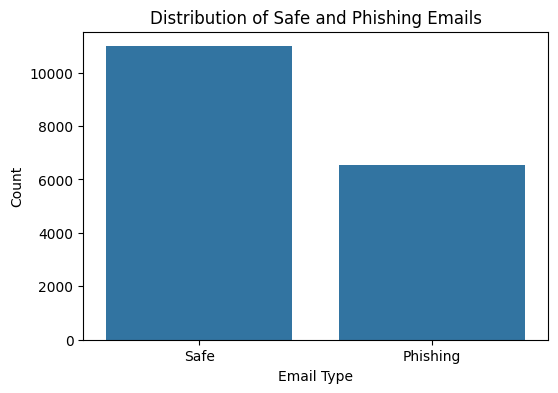

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(data=email_df, x="Label")

plt.xticks([0,1], ["Safe", "Phishing"])
plt.title("Distribution of Safe and Phishing Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.savefig("email_distribution.png")
plt.show()

## Text Preprocessing

Natural Language Processing (NLP) techniques were applied to prepare the email text for machine learning.

The preprocessing pipeline includes:
- Converting text to lowercase
- Removing URLs
- Removing email addresses
- Removing numbers
- Removing punctuation
- Removing stopwords
- Lemmatization

In [34]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [35]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [36]:
def clean_email(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [37]:
email_df["Clean_Text"] = email_df["Email Text"].apply(clean_email)

In [39]:
email_df[["Email Text", "Clean_Text"]].head()

,Email Text,Clean_Text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term name im...
2,re : equistar deal tickets are you still avail...,equistar deal ticket still available assist ro...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horny toy one dream open minded ...
4,software at incredibly low prices ( 86 % lower...,software incredibly low price lower drapery se...


## Feature Engineering

Two types of features were used:

### 1. TF-IDF Features
The cleaned email text was converted into numerical vectors using the TF-IDF (Term Frequency-Inverse Document Frequency) technique.

### 2. Metadata Features
Additional email characteristics were extracted, including:
- Email length
- Word count
- Number of URLs
- Number of email addresses
- Number of digits
- Number of exclamation marks

These features capture structural characteristics commonly found in phishing emails.

In [40]:
# Number of characters
email_df["email_length"] = email_df["Email Text"].apply(len)

# Number of words
email_df["word_count"] = email_df["Email Text"].apply(lambda x: len(str(x).split()))

# Number of URLs
email_df["url_count"] = email_df["Email Text"].apply(
    lambda x: len(re.findall(r'http[s]?://|www\.', str(x)))
)

# Number of email addresses
email_df["email_address_count"] = email_df["Email Text"].apply(
    lambda x: len(re.findall(r'\S+@\S+', str(x)))
)

# Number of digits
email_df["digit_count"] = email_df["Email Text"].apply(
    lambda x: sum(c.isdigit() for c in str(x))
)

# Number of exclamation marks
email_df["exclamation_count"] = email_df["Email Text"].apply(
    lambda x: str(x).count("!")
)

email_df.head()

,Email Text,Email Type,Label,Clean_Text,email_length,word_count,url_count,email_address_count,digit_count,exclamation_count,suspicious_word_count
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0,disc uniformitarianism sex lang dick hudson ob...,1030,230,0,0,9,2,0
1,the other side of * galicismos * * galicismo *...,Safe Email,0,side galicismos galicismo spanish term name im...,479,91,0,0,0,0,0
2,re : equistar deal tickets are you still avail...,Safe Email,0,equistar deal ticket still available assist ro...,1245,305,0,0,63,0,0
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1,hello hot lil horny toy one dream open minded ...,688,96,2,0,29,1,2
4,software at incredibly low prices ( 86 % lower...,Phishing Email,1,software incredibly low price lower drapery se...,441,91,0,0,2,0,0


In [41]:
suspicious_words = [
    "urgent",
    "verify",
    "click",
    "password",
    "account",
    "bank",
    "login",
    "confirm",
    "security",
    "limited",
    "update",
    "free",
    "winner",
    "claim",
    "payment"
]

In [47]:
def count_suspicious_words(text):
    text = str(text).lower()
    count = 0

    for word in suspicious_words:
        count += text.count(word)

    return count

email_df["suspicious_word_count"] = email_df["Clean_Text"].apply(count_suspicious_words)

email_df.head()

,Email Text,Email Type,Label,Clean_Text,email_length,word_count,url_count,email_address_count,digit_count,exclamation_count,suspicious_word_count
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0,disc uniformitarianism sex lang dick hudson ob...,1030,230,0,0,9,2,0
1,the other side of * galicismos * * galicismo *...,Safe Email,0,side galicismos galicismo spanish term name im...,479,91,0,0,0,0,0
2,re : equistar deal tickets are you still avail...,Safe Email,0,equistar deal ticket still available assist ro...,1245,305,0,0,63,0,0
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1,hello hot lil horny toy one dream open minded ...,688,96,2,0,29,1,2
4,software at incredibly low prices ( 86 % lower...,Phishing Email,1,software incredibly low price lower drapery se...,441,91,0,0,2,0,0


In [48]:


from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X = vectorizer.fit_transform(email_df["Clean_Text"])

y = email_df["Label"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (17538, 5000)


## Train-Test Split

The dataset was divided into training (80%) and testing (20%) sets using stratified sampling to preserve the class distribution.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (14030, 5000)
Testing Set  : (3508, 5000)


## Model Training

Four machine learning algorithms were trained and compared:

- Logistic Regression
- Naive Bayes
- Random Forest
- Neural Network

Each model was evaluated using the same training and testing datasets.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [51]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Naive Bayes": MultinomialNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    )

}

In [52]:
results = []

for name, model in models.items():

    print("="*60)
    print(name)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Logistic Regression
Accuracy : 0.9718
Precision: 0.9676
Recall   : 0.9566
F1 Score : 0.9621
Naive Bayes
Accuracy : 0.9618
Precision: 0.9524
Recall   : 0.9451
F1 Score : 0.9487
Random Forest
Accuracy : 0.9684
Precision: 0.9546
Recall   : 0.9611
F1 Score : 0.9578
Neural Network
Accuracy : 0.9755
Precision: 0.9637
Recall   : 0.9710
F1 Score : 0.9674


## Model Evaluation

The performance of each model was measured using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

The Neural Network achieved the highest accuracy and was selected as the final model.

In [53]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Neural Network,0.975485,0.963691,0.971037,0.967350
1,Logistic Regression,0.971779,0.967618,0.956555,0.962054
2,Random Forest,0.968358,0.954580,0.961128,0.957843
3,Naive Bayes,0.961802,0.952381,0.945122,0.948738


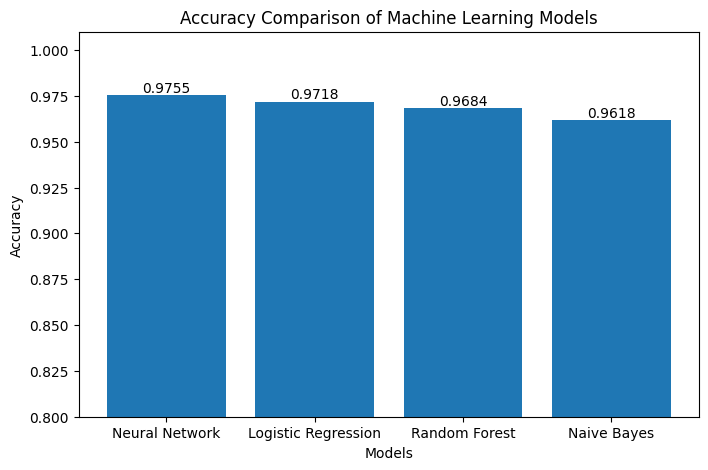

In [57]:
plt.figure(figsize=(8,5))

bars = plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.80,1.01)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.savefig("model_comparison.png")
plt.show()

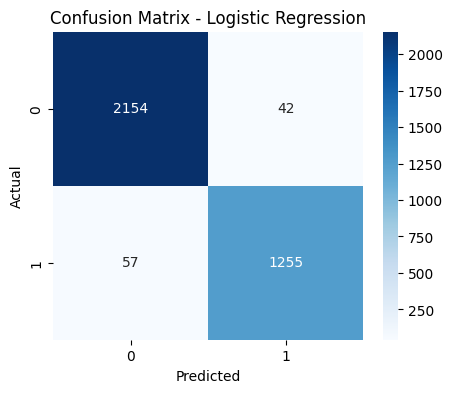

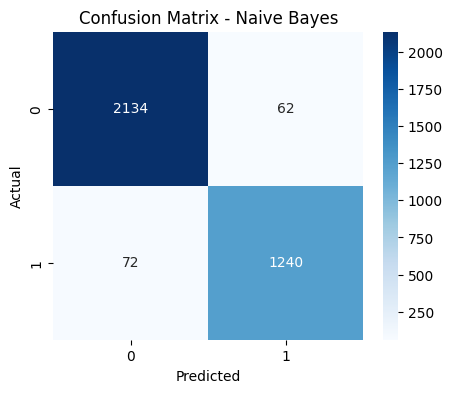

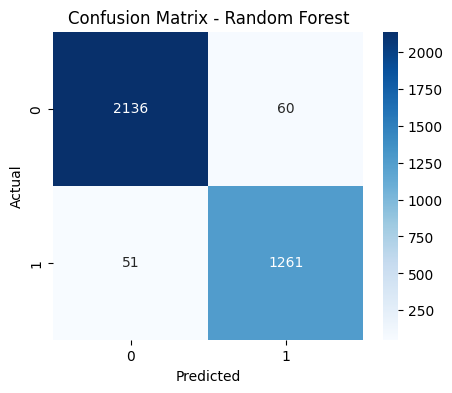

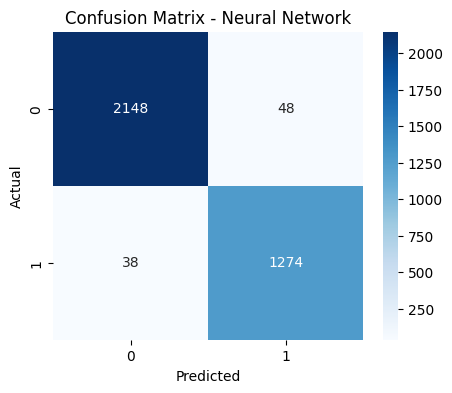

In [58]:
for name, model in models.items():

    predictions = model.predict(X_test)

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{name}_confusion_matrix.png")

    plt.show()

## Model Saving

The best-performing Neural Network model and the TF-IDF vectorizer were saved using Joblib for future deployment in a web application.

In [59]:
import joblib

best_model = models["Neural Network"]

joblib.dump(best_model, "phishing_neural_network.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Best model saved successfully!")

Best model saved successfully!


## Custom Email Prediction

A prediction function was developed to classify new email messages as either Safe or Phishing using the saved Neural Network model.

In [60]:
def predict_email(email):

    cleaned_email = clean_email(email)

    email_vector = vectorizer.transform([cleaned_email])

    prediction = best_model.predict(email_vector)[0]

    if prediction == 1:
        return "🚨 Phishing Email"

    return "✅ Safe Email"

In [61]:
phishing_email = """
Dear Customer,

Your account has been suspended.

Please verify your account immediately by clicking the secure link below.

http://secure-login-verification.com

Failure to verify within 24 hours will permanently suspend your account.
"""

print(predict_email(phishing_email))

🚨 Phishing Email


In [62]:
safe_email = """
Hi Shruti,

The project meeting has been rescheduled to tomorrow at 2 PM.

Please bring your internship progress report.

Thanks,
Project Coordinator
"""

print(predict_email(safe_email))

✅ Safe Email


In [63]:
results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


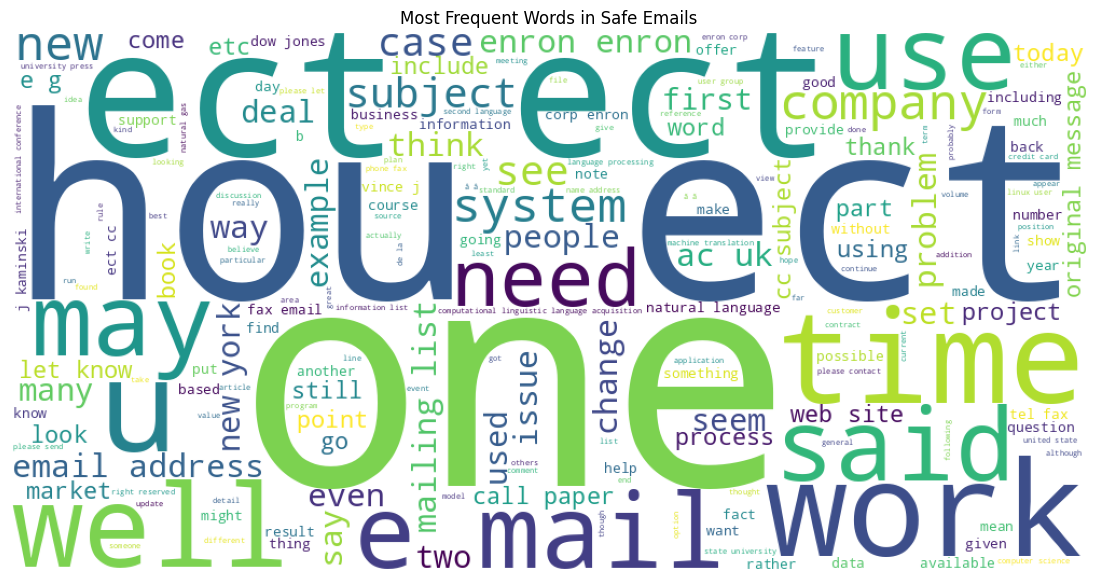

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all safe email text
safe_words = " ".join(email_df[email_df["Label"] == 0]["Clean_Text"])

# Generate Word Cloud
safe_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(safe_words)

# Display
plt.figure(figsize=(14,7))
plt.imshow(safe_wc)
plt.axis("off")
plt.title("Most Frequent Words in Safe Emails")
plt.savefig("safe_email_wordcloud.png")
plt.show()

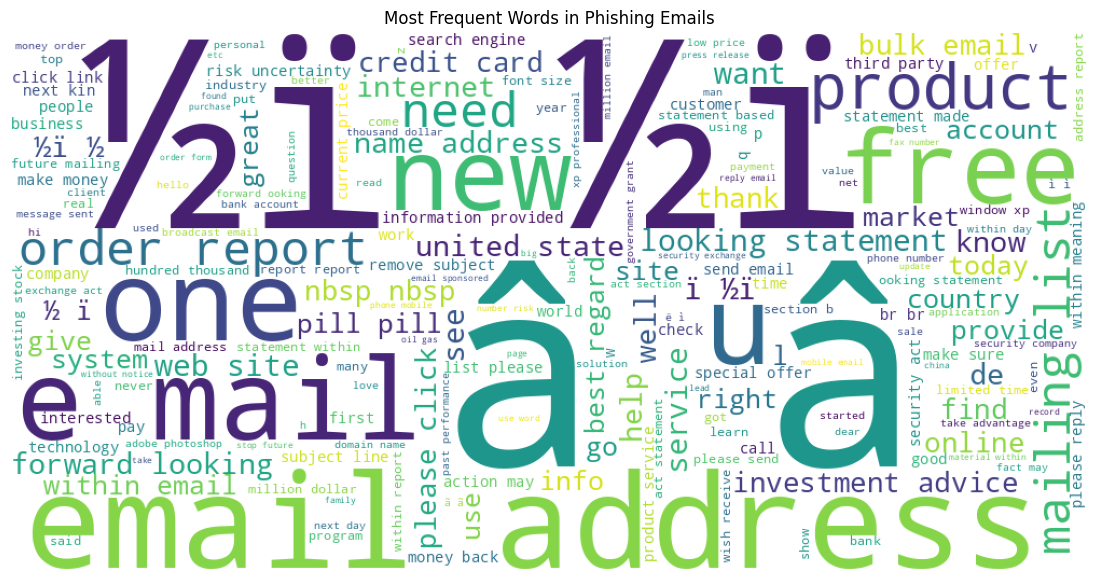

In [65]:
# Combine all phishing email text
phishing_words = " ".join(email_df[email_df["Label"] == 1]["Clean_Text"])

# Generate Word Cloud
phishing_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(phishing_words)

# Display
plt.figure(figsize=(14,7))
plt.imshow(phishing_wc)
plt.axis("off")
plt.title("Most Frequent Words in Phishing Emails")
plt.savefig("phishing_email_wordcloud.png")
plt.show()

In [66]:
from google.colab import files

In [67]:

files.download("phishing_neural_network.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("model_comparison_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
files_to_download = [
    "Logistic Regression_confusion_matrix.png",
    "Naive Bayes_confusion_matrix.png",
    "Random Forest_confusion_matrix.png",
    "Neural Network_confusion_matrix.png",
    "model_comparison.png",
    "phishing_email_wordcloud.png",
    "safe_email_wordcloud.png",
]

for file in files_to_download:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
files.download("email_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

A complete phishing email detection pipeline was successfully implemented using Natural Language Processing and Machine Learning.

Among the evaluated models, the Neural Network achieved the best performance with an accuracy of approximately 97.55%, demonstrating its effectiveness for phishing email classification.

Future improvements may include the use of advanced word embeddings (Word2Vec, GloVe, or BERT) and deployment as a real-time web application using Streamlit or Flask.

## Dataset Acknowledgement

**Dataset Source:** Kaggle – Phishing Email Dataset

**License:** GNU Lesser General Public License v3.0 (GNU LGPL v3.0)

This dataset is used solely for educational and academic purposes as part of the Summer Internship Program in AI & Machine Learning 2026. The dataset remains subject to its original GNU LGPL v3.0 license, and appropriate acknowledgment will also be provided in the project report, presentation, and README.